In [116]:
import math
import os
import csv
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d

In [117]:
data_root = 'data'
user_number = '2'  # matches recorder -u / --user-number
diameter_mm = 80  # matches recorder -s / --diameter-mm
task_performed = 'yaw'  # matches recorder -t / --task-performed
trial_number = '1'  # matches recorder -tn / --trial-number


def get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    return os.path.join(
        data_root,
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
        f'trial_{trial_number}',
    )


def get_synced_data_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    save_dir = os.path.join(
        data_root,
        'synced_data',
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
        f'trial_{trial_number}',
    )
    os.makedirs(save_dir, exist_ok=True)
    return save_dir


def get_segmented_file_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    save_dir = os.path.join(
        data_root,
        'segmented_data',
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
    )
    os.makedirs(save_dir, exist_ok=True)
    return os.path.join(save_dir, f'trial_{trial_number}.csv')


# Recorder input layout example:
# data/user_1/50mm/roll/trial_1/index.csv
data_dir = get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number)
file_dir = get_segmented_file_dir(data_root, user_number, diameter_mm, task_performed, trial_number)
synced_dir = get_synced_data_dir(data_root, user_number, diameter_mm, task_performed, trial_number)

zero_height = 0.2

# Per-trial threshold overrides can live here when a specific recording needs them.
zero_height_overrides = {
    # ('1', 50, 'pitch', '1'): 0.01,
}
zero_height = zero_height_overrides.get(
    (str(user_number), int(diameter_mm), task_performed, str(trial_number)),
    zero_height,
)

In [118]:
def load_data(data_dir):
    thumb_path = os.path.join(data_dir, 'thumb.csv')
    index_path = os.path.join(data_dir, 'index.csv')
    middle_path = os.path.join(data_dir, 'middle.csv')

    thumb = pd.read_csv(thumb_path)
    index = pd.read_csv(index_path)
    middle = pd.read_csv(middle_path)

    thumb_time = thumb["source_timestamp_sec"].to_numpy(dtype=float)
    index_time = index["source_timestamp_sec"].to_numpy(dtype=float)
    middle_time = middle["source_timestamp_sec"].to_numpy(dtype=float)

    time_start = max(thumb_time[0], index_time[0], middle_time[0])
    time_end = min(thumb_time[-1], index_time[-1], middle_time[-1])

    thumb_time = thumb_time - time_start
    index_time = index_time - time_start
    middle_time = middle_time - time_start
    time_end = time_end - time_start

    mask = (thumb_time >= 0) & (thumb_time <= time_end)

    synced_time = thumb_time[mask]

    # Thumb is the reference timeline, so no interpolation needed
    thumb_sync = thumb[["Fx", "Fy", "Fz"]].to_numpy(dtype=float)[mask]

    def interpolate_sensor(sensor_df, sensor_time):
        synced_sensor = np.zeros((len(synced_time), 3))

        for i, col in enumerate(["Fx", "Fy", "Fz"]):
            values = sensor_df[col].to_numpy(dtype=float)
            valid_indices = ~np.isnan(values)

            interp_func = interp1d(
                sensor_time[valid_indices],
                values[valid_indices],
                kind="linear",
                fill_value="extrapolate"
            )

            synced_sensor[:, i] = interp_func(synced_time)

        return synced_sensor

    index_sync = interpolate_sensor(index, index_time)
    middle_sync = interpolate_sensor(middle, middle_time)

    force_data = np.column_stack([
        thumb_sync,
        index_sync,
        middle_sync
    ])

    return force_data, synced_time

In [119]:
def save_synced_data(save_dir, synced_time, force_data):
    """
    Saves the synced/interpolated force data to 3 separate csv files,
    one per finger: synced_thumb.csv, synced_index.csv, synced_middle.csv.
    Each file has columns: time, Fx, Fy, Fz.
    """
    fingers = ["thumb", "index", "middle"]
    os.makedirs(save_dir, exist_ok=True)

    for i, finger in enumerate(fingers):
        df = pd.DataFrame({
            "time": synced_time,
            "Fx": force_data[:, i * 3],
            "Fy": force_data[:, i * 3 + 1],
            "Fz": force_data[:, i * 3 + 2],
        })
        path = os.path.join(save_dir, f"synced_{finger}.csv")
        df.to_csv(path, index=False)
        print(f"Saved {finger} synced data to {path}")


def load_synced_data(save_dir):
    """
    Loads the synced/interpolated force data back from the 3 per-finger csv
    files written by save_synced_data, and reconstructs force_data and
    synced_time in the same layout used elsewhere in this notebook
    (columns: thumb Fx,Fy,Fz, index Fx,Fy,Fz, middle Fx,Fy,Fz).
    """
    fingers = ["thumb", "index", "middle"]
    force_list = []
    synced_time = None

    for finger in fingers:
        path = os.path.join(save_dir, f"synced_{finger}.csv")
        df = pd.read_csv(path)

        if synced_time is None:
            synced_time = df["time"].to_numpy(dtype=float)
        elif not np.allclose(synced_time, df["time"].to_numpy(dtype=float)):
            raise ValueError(f"Time column in {finger} synced data does not match thumb's time column.")

        force_list.append(df[["Fx", "Fy", "Fz"]].to_numpy(dtype=float))

    force_data = np.column_stack(force_list)
    return force_data, synced_time


In [120]:
def pca_analysis(data, n_components=9, force_threshold=0.1):
    print(f"Before clipping, data samples: {data.shape[0]}")
    if n_components == 9:
        s1_force = data[:, 0:3]
        s2_force = data[:, 3:6]
        s3_force = data[:, 6:9]
        s1_norm_force = np.linalg.norm(s1_force, axis=1).reshape(-1, 1)
        s2_norm_force = np.linalg.norm(s2_force, axis=1).reshape(-1, 1)
        s3_norm_force = np.linalg.norm(s3_force, axis=1).reshape(-1, 1)
        mask_indexes = []
        for i in range(s1_norm_force.shape[0]):
            if s1_norm_force[i] < force_threshold and s2_norm_force[i] < force_threshold and s3_norm_force[i] < force_threshold:
                mask_indexes.append(i)
        data_filtered = np.delete(data, mask_indexes, axis=0)
    elif n_components == 18:
        s1_force = data[:, 0:3]
        s2_force = data[:, 6:9]
        s3_force = data[:, 12:15]
        s1_norm_force = np.linalg.norm(s1_force, axis=1).reshape(-1, 1)
        s2_norm_force = np.linalg.norm(s2_force, axis=1).reshape(-1, 1)
        s3_norm_force = np.linalg.norm(s3_force, axis=1).reshape(-1, 1)
        mask_indexes = []
        for i in range(s1_norm_force.shape[0]):
            if s1_norm_force[i] < force_threshold and s2_norm_force[i] < force_threshold and s3_norm_force[i] < force_threshold:
                mask_indexes.append(i)
        data_filtered = np.delete(data, mask_indexes, axis=0)
        scaler = StandardScaler()
        data_filtered = scaler.fit_transform(data_filtered)

    print(f"After clipping, data samples: {data_filtered.shape[0]}")

    pca = PCA(n_components=n_components)
    pca.fit_transform(data_filtered)
    return pca.components_, pca.explained_variance_, pca.explained_variance_ratio_

In [121]:
def plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed: bool=False):

    # ==== Print PCA summary ====
    print("PC  | Eigenvalue | Variance Ratio")
    print("-" * 40)
    for i, (val, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
        print(f"PC{i+1:<3} | {val:<10.4f} | {ratio:.2%}")
    print("-" * 40)
    print(f"Sum of eigenvalues: {np.sum(eigenvalues):.4f}\n")

    # ==== Build DataFrame ====
    if transformed:
        axis_labels = ['Grav', 'Lateral', 'Normal'] * 3
    else:
        axis_labels = ['Fx', 'Fy', 'Fz'] * 3
    pc_names = [f'PC{i+1}' for i in range(pca_components.shape[0])]
    df = pd.DataFrame(pca_components.T, index=axis_labels, columns=pc_names)

    # ==== Plot ====
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.6,              # cell borders
        linecolor="gray",            # gray boudnary lines
        cbar_kws={"label": "Loading Weight"}
    )

    # seperate three fingers
    for y in [3, 6]:
        ax.axhline(y, color="black", lw=2, ls="-")

    # label the finger
    for y, label in zip([1.5, 4.5, 7.5], ["Thumb", "Index", "Middle"]):
        ax.text(-0.05, y, label,
                va="center", ha="right",
                rotation=90,
                transform=ax.get_yaxis_transform())

    # boundaries
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    plt.title(f'{task_performed.capitalize()}, Trial {trial_number}: PCA Loadings')
    plt.xlabel("Principal Components")
    plt.ylabel("Force Sensors", labelpad=20)
    plt.tight_layout()
    plt.show()

In [122]:
def plot_pca_heatmap_horizontal_ft(pca_components, eigenvalues, explained_variance_ratio):

    # ==== Print PCA summary ====
    print("PC  | Eigenvalue | Variance Ratio")
    print("-" * 40)
    for i, (val, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
        print(f"PC{i+1:<3} | {val:<10.4f} | {ratio:.2%}")
    print("-" * 40)
    print(f"Sum of eigenvalues: {np.sum(eigenvalues):.4f}\n")

    # ==== Build DataFrame ====
    axis_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz'] * 3
    pc_names = [f'PC{i+1}' for i in range(pca_components.shape[0])]
    df = pd.DataFrame(pca_components.T, index=axis_labels, columns=pc_names)

    # ==== Plot ====
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.6,              # cell borders
        linecolor="gray",            # gray boudnary lines
        cbar_kws={"label": "Loading Weight"}
    )

    # seperate three fingers
    for y in [6, 12]:
        ax.axhline(y, color="black", lw=2, ls="-")

    # label the finger
    for y, label in zip([3, 9, 15], ["Thumb", "Index", "Middle"]):
        ax.text(-0.05, y, label,
                va="center", ha="right",
                rotation=90,
                transform=ax.get_yaxis_transform())

    # boundaries
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    plt.title(f'{task_performed.capitalize()}, Trial {trial_number}: PCA Loadings')
    plt.xlabel("Principal Components")
    plt.ylabel("Force and Torque Sensors", labelpad=20)
    plt.tight_layout()
    plt.show()

In [123]:
def pca_analysis_and_plot(data, transformed_flag=True, visualize=True):
    pca_components, eigenvalues, explained_variance_ratio = pca_analysis(data, data.shape[1])
    if visualize:
        plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed_flag)

In [124]:
def main_analysis(data_dir):
    force_data, synced_time = load_data(data_dir)
    print('Recorded Force Data Analysis:')
    pca_components, eigenvalues, explained_variance_ratio = pca_analysis(force_data, force_data.shape[1])
    plot_pca_heatmap_horizontal_forces(pca_components, eigenvalues, explained_variance_ratio, transformed=False)

In [125]:
def quick_visualization(force_data, synced_time, visualize_data='recorded'):

    max_val = np.max(force_data)
    min_val = np.min(force_data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(311)
    ax1.plot(synced_time,force_data[:, 0])
    ax1.plot(synced_time,force_data[:, 1])
    ax1.plot(synced_time,force_data[:, 2])
    ax1.set_title(f'{visualize_data.capitalize()} Force Data - Thumb')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Force (N)')
    ax1.legend(['Fx', 'Fy', 'Fz'])
    ax1.set_ylim(low_bound, up_bound)

    ax2 = fig.add_subplot(312)
    ax2.plot(synced_time,force_data[:, 3])
    ax2.plot(synced_time,force_data[:, 4])
    ax2.plot(synced_time,force_data[:, 5])
    ax2.set_title(f'{visualize_data.capitalize()} Force Data - Index')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Force (N)')
    ax2.legend(['Fx', 'Fy', 'Fz'])
    ax2.set_ylim(low_bound, up_bound)

    ax3 = fig.add_subplot(313)
    ax3.plot(synced_time,force_data[:, 6])
    ax3.plot(synced_time,force_data[:, 7])
    ax3.plot(synced_time,force_data[:, 8])
    ax3.set_title(f'{visualize_data.capitalize()} Force Data - Middle')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Force (N)')
    ax3.legend(['Fx', 'Fy', 'Fz'])
    ax3.set_ylim(low_bound, up_bound)
    
    plt.tight_layout()
    plt.show()

In [126]:
def split_contiguous_regions(idx):
    """
    Split sorted sample indices into contiguous regions.

    Example:
        [1, 2, 3, 5, 6, 10] -> [(1, 3), (5, 6), (10, 10)]
    """
    idx = np.asarray(idx, dtype=int)

    if idx.size == 0:
        return []

    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    return [(int(group[0]), int(group[-1])) for group in groups]


def get_movement_regions(common_zero_idx, total_len, min_zero_duration=50):
    """
    Use long regions where all three fingers are near zero to create candidate
    movement regions.

    Candidate regions are also allowed before the first shared-zero region and
    after the final shared-zero region.
    """
    zero_regions = split_contiguous_regions(common_zero_idx)
    zero_regions = [
        region
        for region in zero_regions
        if (region[1] - region[0] + 1) >= min_zero_duration
    ]

    if total_len <= 0:
        return []

    if not zero_regions:
        return [(0, total_len - 1)]

    movement_regions = []

    # Movement before the first long common-zero region.
    if zero_regions[0][0] > 0:
        movement_regions.append((0, zero_regions[0][0] - 1))

    # Movement between consecutive long common-zero regions.
    for left_zero, right_zero in zip(zero_regions[:-1], zero_regions[1:]):
        start = left_zero[1] + 1
        end = right_zero[0] - 1

        if start <= end:
            movement_regions.append((start, end))

    # Movement after the final long common-zero region.
    if zero_regions[-1][1] < total_len - 1:
        movement_regions.append((zero_regions[-1][1] + 1, total_len - 1))

    return movement_regions


def build_shared_peak_segments(
    movement_regions,
    peaks_thumb,
    peaks_index,
    peaks_middle,
    peak_pad=5,
    total_len=None,
):
    """
    Build one shared segment for each candidate movement.

    For every candidate movement:
        shared start = latest first peak across thumb, index, and middle
        shared end   = earliest second-to-last peak across all three fingers

    Taking the latest first peak means all three fingers have produced their
    first detected peak before the highlighted segment starts.

    Taking the earliest second-to-last peak means the highlighted segment ends
    while all three fingers still have at least one later peak remaining.

    A candidate movement is skipped unless every finger has at least two peaks.
    """
    peaks_thumb = np.asarray(peaks_thumb, dtype=int)
    peaks_index = np.asarray(peaks_index, dtype=int)
    peaks_middle = np.asarray(peaks_middle, dtype=int)

    if total_len is None:
        all_endpoints = [end for _, end in movement_regions]
        total_len = max(all_endpoints, default=-1) + 1

    shared_segments = []

    for region_number, (region_start, region_end) in enumerate(movement_regions, start=1):
        thumb_region_peaks = peaks_thumb[
            (peaks_thumb >= region_start) & (peaks_thumb <= region_end)
        ]
        index_region_peaks = peaks_index[
            (peaks_index >= region_start) & (peaks_index <= region_end)
        ]
        middle_region_peaks = peaks_middle[
            (peaks_middle >= region_start) & (peaks_middle <= region_end)
        ]

        peak_counts = {
            "thumb": len(thumb_region_peaks),
            "index": len(index_region_peaks),
            "middle": len(middle_region_peaks),
        }

        # The second-to-last peak only exists when each finger has >= 2 peaks.
        if min(peak_counts.values()) < 2:
            print(
                f"Skipping candidate movement {region_number}: "
                f"not enough peaks for every finger {peak_counts}."
            )
            continue

        # Wait until all three fingers have reached their first peak.
        shared_start_peak = max(
            thumb_region_peaks[1],
            index_region_peaks[1],
            middle_region_peaks[1],
        )

        # Stop at the earliest second-to-last peak so all three are still active.
        shared_end_peak = min(
            thumb_region_peaks[-2],
            index_region_peaks[-2],
            middle_region_peaks[-2],
        )

        if shared_start_peak > shared_end_peak:
            print(
                f"Skipping candidate movement {region_number}: "
                f"shared start peak {shared_start_peak} occurs after "
                f"shared end peak {shared_end_peak}."
            )
            continue

        segment_start = max(shared_start_peak - peak_pad, 0)
        segment_end = min(shared_end_peak + peak_pad, total_len - 1)

        shared_segments.append({
            "start": int(segment_start),
            "end": int(segment_end),
            "start_peak": int(shared_start_peak),
            "end_peak": int(shared_end_peak),
            "thumb_peaks": thumb_region_peaks,
            "index_peaks": index_region_peaks,
            "middle_peaks": middle_region_peaks,
        })

    return shared_segments


def mask_calculation(
    force_data,
    synced_time,
    data_height=0.3,
    zero_height=0.5,
    visualize=True,
    peak_pad=5,
    min_zero_duration=50,
):
    """
    Detect peaks and return only the shared movement data.

    Highlighting/segmentation rule:
        1. Use long common-zero regions to separate candidate movements.
        2. In each candidate movement, require at least two peaks from every finger.
        3. Start at the latest first peak across the three fingers.
        4. End at the earliest second-to-last peak across the three fingers.
        5. Apply peak_pad samples of margin to both sides.
    """
    if force_data.ndim != 2 or force_data.shape[1] < 9:
        raise ValueError(
            "force_data must be a 2D array with at least 9 columns "
            "(Thumb Fx/Fy/Fz, Index Fx/Fy/Fz, Middle Fx/Fy/Fz)."
        )

    if len(synced_time) != force_data.shape[0]:
        raise ValueError("synced_time and force_data must contain the same number of samples.")

    if peak_pad < 0:
        raise ValueError("peak_pad must be zero or greater.")

    peaks_thumb_z = find_peaks(
        np.abs(force_data[:, 2]),
        height=data_height,
        distance=20,
        prominence=0.05,
    )[0]
    peaks_index_z = find_peaks(
        np.abs(force_data[:, 5]),
        height=data_height,
        distance=20,
        prominence=0.05,
    )[0]
    peaks_middle_z = find_peaks(
        np.abs(force_data[:, 8]),
        height=data_height,
        distance=20,
        prominence=0.05,
    )[0]

    thumb_z_smooth = uniform_filter1d(np.abs(force_data[:, 2]), size=10)
    index_z_smooth = uniform_filter1d(np.abs(force_data[:, 5]), size=10)
    middle_z_smooth = uniform_filter1d(np.abs(force_data[:, 8]), size=10)

    zero_idx_thumb_z = np.where(thumb_z_smooth < zero_height)[0]
    zero_idx_index_z = np.where(index_z_smooth < zero_height)[0]
    zero_idx_middle_z = np.where(middle_z_smooth < zero_height)[0]

    # A shared zero sample exists only when all three fingers are below the
    # zero threshold at the same time.
    common_zero_mask = (
        (thumb_z_smooth < zero_height)
        & (index_z_smooth < zero_height)
        & (middle_z_smooth < zero_height)
    )
    common_zero_idx = np.where(common_zero_mask)[0]

    print("Detected peaks:")
    print("Thumb:", len(peaks_thumb_z))
    print("Index:", len(peaks_index_z))
    print("Middle:", len(peaks_middle_z))

    print("\nIndividual zero samples:")
    print("Thumb:", len(zero_idx_thumb_z))
    print("Index:", len(zero_idx_index_z))
    print("Middle:", len(zero_idx_middle_z))
    print("Common zero samples:", len(common_zero_idx))

    movement_regions = get_movement_regions(
        common_zero_idx,
        total_len=force_data.shape[0],
        min_zero_duration=min_zero_duration,
    )

    shared_segments = build_shared_peak_segments(
        movement_regions=movement_regions,
        peaks_thumb=peaks_thumb_z,
        peaks_index=peaks_index_z,
        peaks_middle=peaks_middle_z,
        peak_pad=peak_pad,
        total_len=force_data.shape[0],
    )

    print(f"\nCandidate movement regions: {len(movement_regions)}")
    print(f"Valid shared peak segments: {len(shared_segments)}")

    if not shared_segments:
        print(
            "No valid shared peak segments were found. "
            "Each movement needs at least two detected peaks from every finger."
        )
        return np.empty((0, force_data.shape[1]))

    max_val = np.max(force_data)
    min_val = np.min(force_data)
    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    axes = None

    if visualize:
        fig = plt.figure(figsize=(12, 8))
        ax1 = fig.add_subplot(311)
        ax2 = fig.add_subplot(312)
        ax3 = fig.add_subplot(313)
        axes = (ax1, ax2, ax3)

        finger_plot_info = [
            (ax1, 0, 1, 2, peaks_thumb_z, zero_idx_thumb_z, "Thumb"),
            (ax2, 3, 4, 5, peaks_index_z, zero_idx_index_z, "Index"),
            (ax3, 6, 7, 8, peaks_middle_z, zero_idx_middle_z, "Middle"),
        ]

        for ax, fx_col, fy_col, fz_col, peaks, zero_idx, finger_name in finger_plot_info:
            ax.plot(synced_time, force_data[:, fx_col])
            ax.plot(synced_time, force_data[:, fy_col])
            ax.plot(synced_time, force_data[:, fz_col])
            ax.plot(
                synced_time[peaks],
                force_data[peaks, fz_col],
                "rx",
                label="Detected Fz peaks",
            )
            ax.plot(
                synced_time[zero_idx],
                force_data[zero_idx, fz_col],
                "ko",
                markersize=3,
                label="Below zero threshold",
            )
            ax.set_title(f"Recorded Force Data - {finger_name}")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Force (N)")
            ax.set_ylim(low_bound, up_bound)
            ax.legend(["Fx", "Fy", "Fz", "Detected Fz peaks", "Below zero threshold"])

    data_mask = []

    for segment_number, segment in enumerate(shared_segments, start=1):
        start_idx = segment["start"]
        end_idx = segment["end"]
        data_mask.extend(range(start_idx, end_idx + 1))

        print(
            f"Segment {segment_number}: "
            f"{synced_time[start_idx]:.3f} s to {synced_time[end_idx]:.3f} s "
            f"(shared peak boundaries: "
            f"{synced_time[segment['start_peak']]:.3f} s to "
            f"{synced_time[segment['end_peak']]:.3f} s)"
        )

        if visualize:
            for ax in axes:
                ax.axvspan(
                    synced_time[start_idx],
                    synced_time[end_idx],
                    color="red",
                    alpha=0.3,
                )
                ax.axvline(
                    synced_time[segment["start_peak"]],
                    color="green",
                    linestyle="--",
                    linewidth=1,
                )
                ax.axvline(
                    synced_time[segment["end_peak"]],
                    color="blue",
                    linestyle="--",
                    linewidth=1,
                )

    # Avoid duplicated samples if two padded segments overlap.
    data_mask = np.unique(np.asarray(data_mask, dtype=int))
    masked_data = force_data[data_mask, :]

    if visualize:
        plt.tight_layout()
        plt.show()

    return masked_data


In [127]:
force_data, synced_time = load_data(data_dir)
save_synced_data(synced_dir, synced_time, force_data)


Saved thumb synced data to data/synced_data/user_2/80mm/yaw/trial_1/synced_thumb.csv
Saved index synced data to data/synced_data/user_2/80mm/yaw/trial_1/synced_index.csv
Saved middle synced data to data/synced_data/user_2/80mm/yaw/trial_1/synced_middle.csv


In [128]:
# Reload the synced data from the csv files we just wrote.
# This lets you open synced_thumb.csv, synced_index.csv, and synced_middle.csv
# by hand to crosscheck the interpolation/time-syncing before continuing.
force_data, synced_time = load_synced_data(synced_dir)
print(f'Reloaded synced data from {synced_dir} for {force_data.shape[0]} samples.')


Reloaded synced data from data/synced_data/user_2/80mm/yaw/trial_1 for 12738 samples.


In [129]:
print("force_data shape:", force_data.shape)

print("Thumb Fz max:", np.max(np.abs(force_data[:, 2])))
print("Index Fz max:", np.max(np.abs(force_data[:, 5])))
print("Middle Fz max:", np.max(np.abs(force_data[:, 8])))

force_data shape: (12738, 9)
Thumb Fz max: 10.978481895
Index Fz max: 10.316554503586952
Middle Fz max: 9.710057092


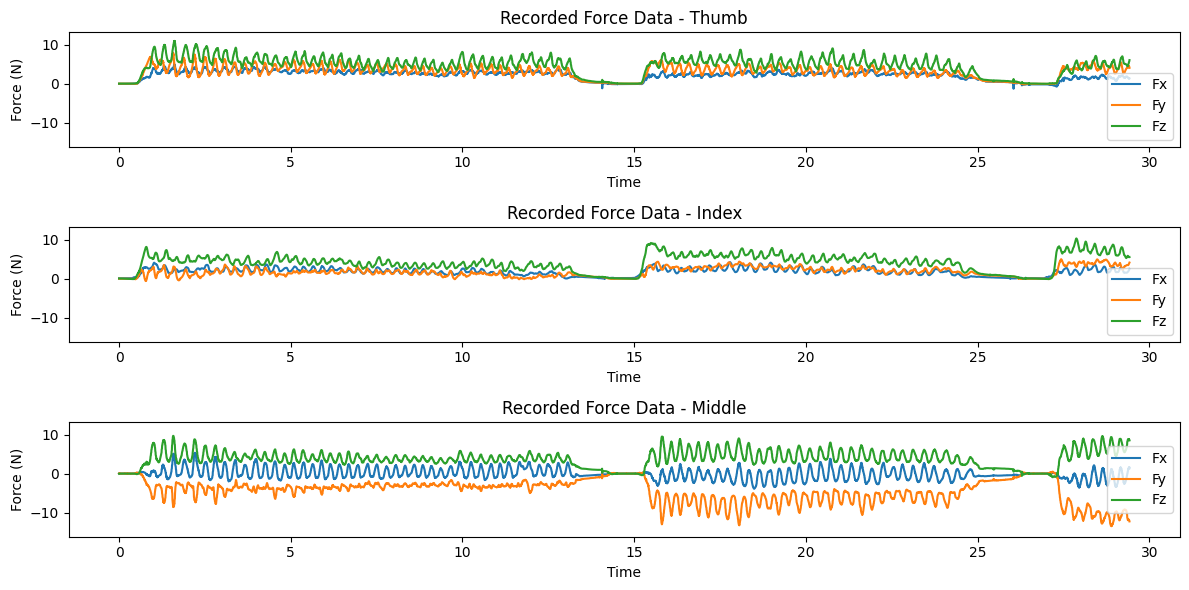

In [130]:
quick_visualization(force_data, synced_time, visualize_data='recorded')

Detected peaks:
Thumb: 120
Index: 133
Middle: 126

Individual zero samples:
Thumb: 1067
Index: 998
Middle: 970
Common zero samples: 873

Candidate movement regions: 3
Valid shared peak segments: 3
Segment 1: 0.793 s to 13.125 s (shared peak boundaries: 0.807 s to 13.112 s)
Segment 2: 15.602 s to 25.368 s (shared peak boundaries: 15.614 s to 25.355 s)
Segment 3: 27.870 s to 29.076 s (shared peak boundaries: 27.882 s to 29.063 s)


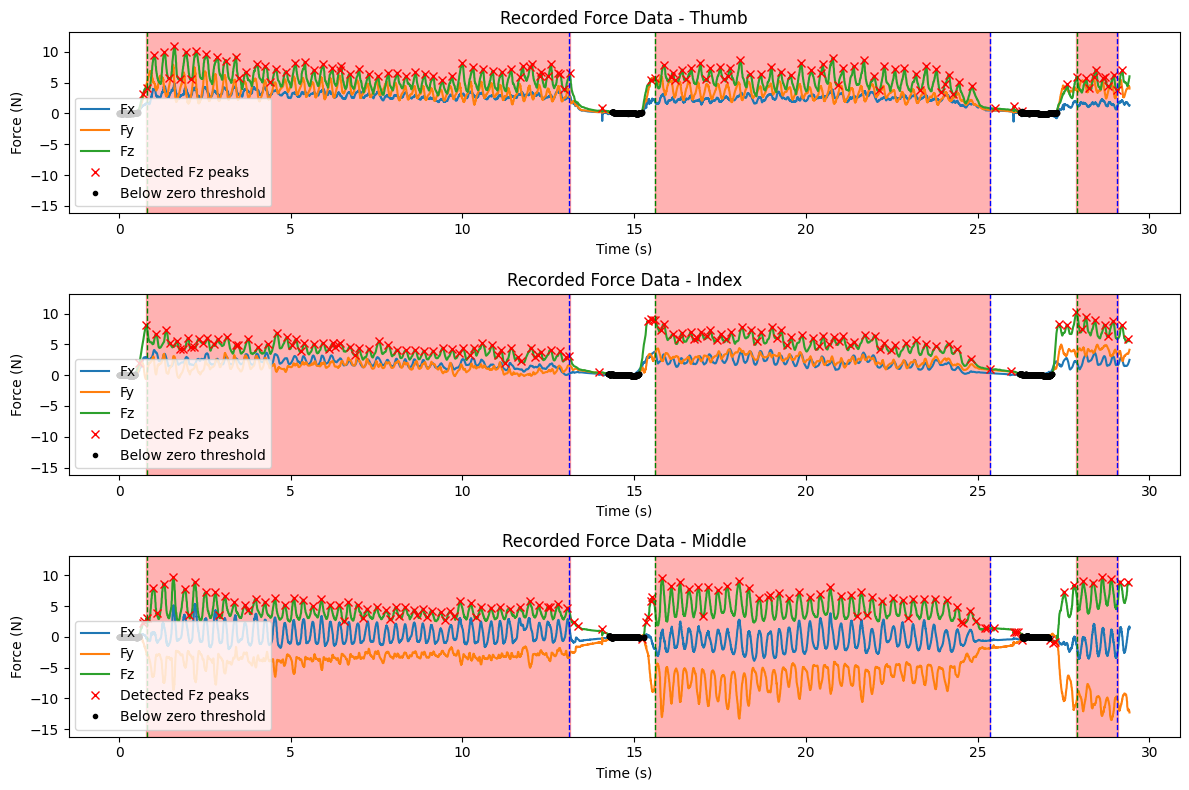

In [131]:
masked_data = mask_calculation( force_data, synced_time, data_height=0.3, zero_height=zero_height)

In [132]:
os.makedirs(os.path.dirname(file_dir), exist_ok=True)

if masked_data.size == 0:
    print(f'Not saving because masked_data is empty: {masked_data.shape}')
else:
    with open(file_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(masked_data)
    print(f'Saved masked data to {file_dir}')

Saved masked data to data/segmented_data/user_2/80mm/yaw/trial_1.csv


Before clipping, data samples: 10121
After clipping, data samples: 10121
PC  | Eigenvalue | Variance Ratio
----------------------------------------
PC1   | 10.6409    | 55.20%
PC2   | 4.8697     | 25.26%
PC3   | 1.8762     | 9.73%
PC4   | 0.8336     | 4.32%
PC5   | 0.3565     | 1.85%
PC6   | 0.3073     | 1.59%
PC7   | 0.1788     | 0.93%
PC8   | 0.1258     | 0.65%
PC9   | 0.0887     | 0.46%
----------------------------------------
Sum of eigenvalues: 19.2776



/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decompo

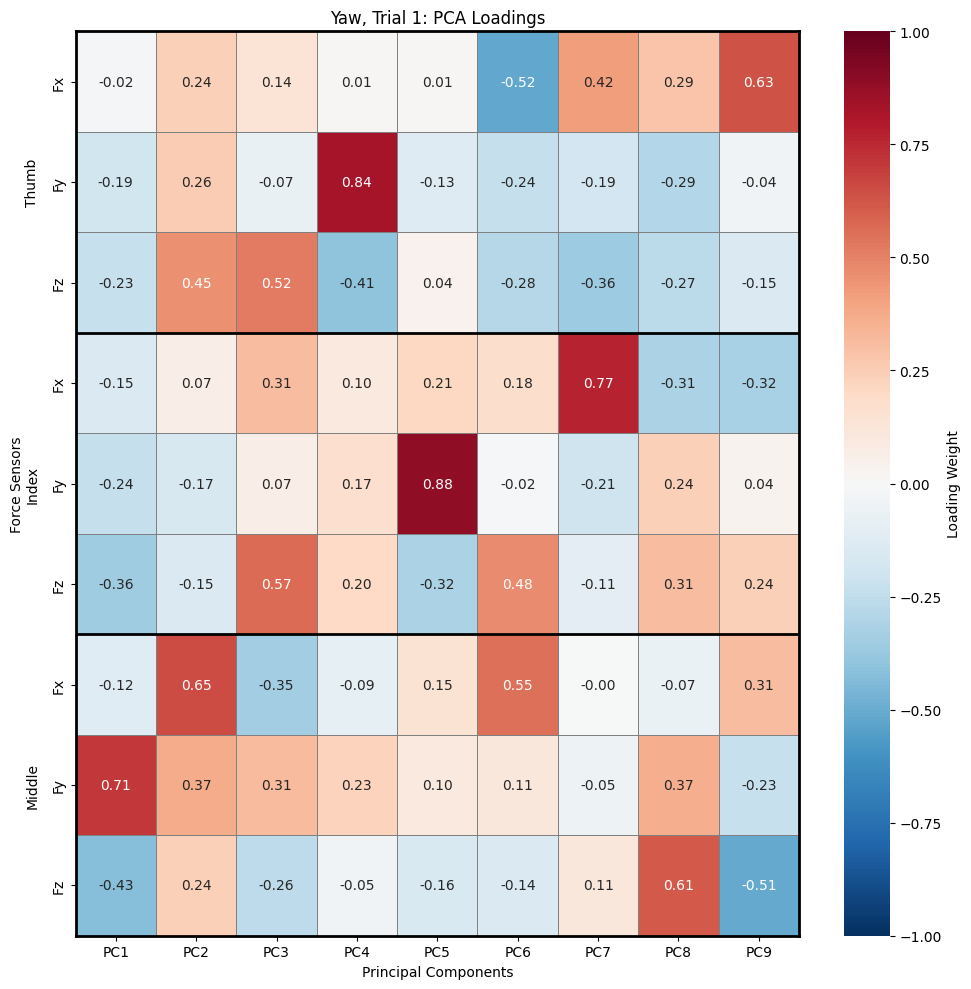

In [133]:
pca_analysis_and_plot(masked_data, transformed_flag=False, visualize=True)